In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from datetime import datetime, timedelta

import yfinance as yf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
end   = datetime.today()
start = end - timedelta(days=365 * 20)

df = yf.Ticker('^NSEI').history(start=start.strftime('%Y-%m-%d'),
                                end=end.strftime('%Y-%m-%d'))['Close'].dropna()
df.index = pd.to_datetime(df.index).tz_localize(None)

test  = df.iloc[-5:]
train = df.iloc[:-5]

train_d1 = train.diff().dropna()
train_d2 = train_d1.diff().dropna()

print(f'Train: {train.index[0].date()} -> {train.index[-1].date()}  ({len(train)} obs)')
print(f'Test : {test.index[0].date()}  -> {test.index[-1].date()}   ({len(test)} obs)')

Train: 2007-09-17 -> 2026-03-19  (4540 obs)
Test : 2026-03-20  -> 2026-03-27   (5 obs)


7(a): ADF & KPSS Stationarity Tests → Select d

In [4]:
def adf_test(series, label):
    r = adfuller(series, autolag='AIC')
    result = 'STATIONARY' if r[1] < 0.05 else 'NON-STATIONARY'
    print(f'  ADF [{label}]:  stat={r[0]:.4f}  p={r[1]:.6f}  lags={r[2]}  -> {result}')
    print(f'    Critical: 1%={r[4]["1%"]:.3f}  5%={r[4]["5%"]:.3f}  10%={r[4]["10%"]:.3f}')

def kpss_test(series, label):
    r = kpss(series, regression='c', nlags='auto')
    result = 'NON-STATIONARY' if r[1] < 0.05 else 'STATIONARY'
    print(f'  KPSS [{label}]: stat={r[0]:.4f}  p={r[1]:.4f}  -> {result}')

print('=== ADF Tests ===')
adf_test(train,    'Original')
adf_test(train_d1, '1st Diff')
adf_test(train_d2, '2nd Diff')

print('\n=== KPSS Tests ===')
kpss_test(train,    'Original')
kpss_test(train_d1, '1st Diff')

=== ADF Tests ===
  ADF [Original]:  stat=0.4074  p=0.981769  lags=30  -> NON-STATIONARY
    Critical: 1%=-3.432  5%=-2.862  10%=-2.567
  ADF [1st Diff]:  stat=-11.9566  p=0.000000  lags=29  -> STATIONARY
    Critical: 1%=-3.432  5%=-2.862  10%=-2.567
  ADF [2nd Diff]:  stat=-19.3683  p=0.000000  lags=32  -> STATIONARY
    Critical: 1%=-3.432  5%=-2.862  10%=-2.567

=== KPSS Tests ===
  KPSS [Original]: stat=9.6243  p=0.0100  -> NON-STATIONARY
  KPSS [1st Diff]: stat=0.1926  p=0.1000  -> STATIONARY


7(b)+(c): Fit ARIMA Models with d = 1 from Tests

In [5]:
MODELS = {
    'ARIMA(1,1,0)': (1,1,0),
    'ARIMA(0,1,1)': (0,1,1),
    'ARIMA(1,1,1)': (1,1,1),
    'ARIMA(2,1,1)': (2,1,1),
    'ARIMA(1,1,2)': (1,1,2),
}

fitted = {}
for name, order in MODELS.items():
    fitted[name] = ARIMA(train, order=order).fit()
    print(f'{name}  ->  AIC={fitted[name].aic:.2f}  BIC={fitted[name].bic:.2f}')

ARIMA(1,1,0)  ->  AIC=56454.95  BIC=56467.79
ARIMA(0,1,1)  ->  AIC=56454.95  BIC=56467.79
ARIMA(1,1,1)  ->  AIC=56456.75  BIC=56476.01
ARIMA(2,1,1)  ->  AIC=56457.86  BIC=56483.54
ARIMA(1,1,2)  ->  AIC=56458.30  BIC=56483.98


In [6]:
true_vals = test.values
forecasts = {name: res.get_forecast(steps=5).predicted_mean.values
             for name, res in fitted.items()}
metrics = {}
for name, fc in forecasts.items():
    rmse = np.sqrt(mean_squared_error(true_vals, fc))
    mae  = mean_absolute_error(true_vals, fc)
    r2   = r2_score(true_vals, fc)
    metrics[name] = (rmse, mae, r2)

7(d): Residual Diagnostics (All 5 Models)

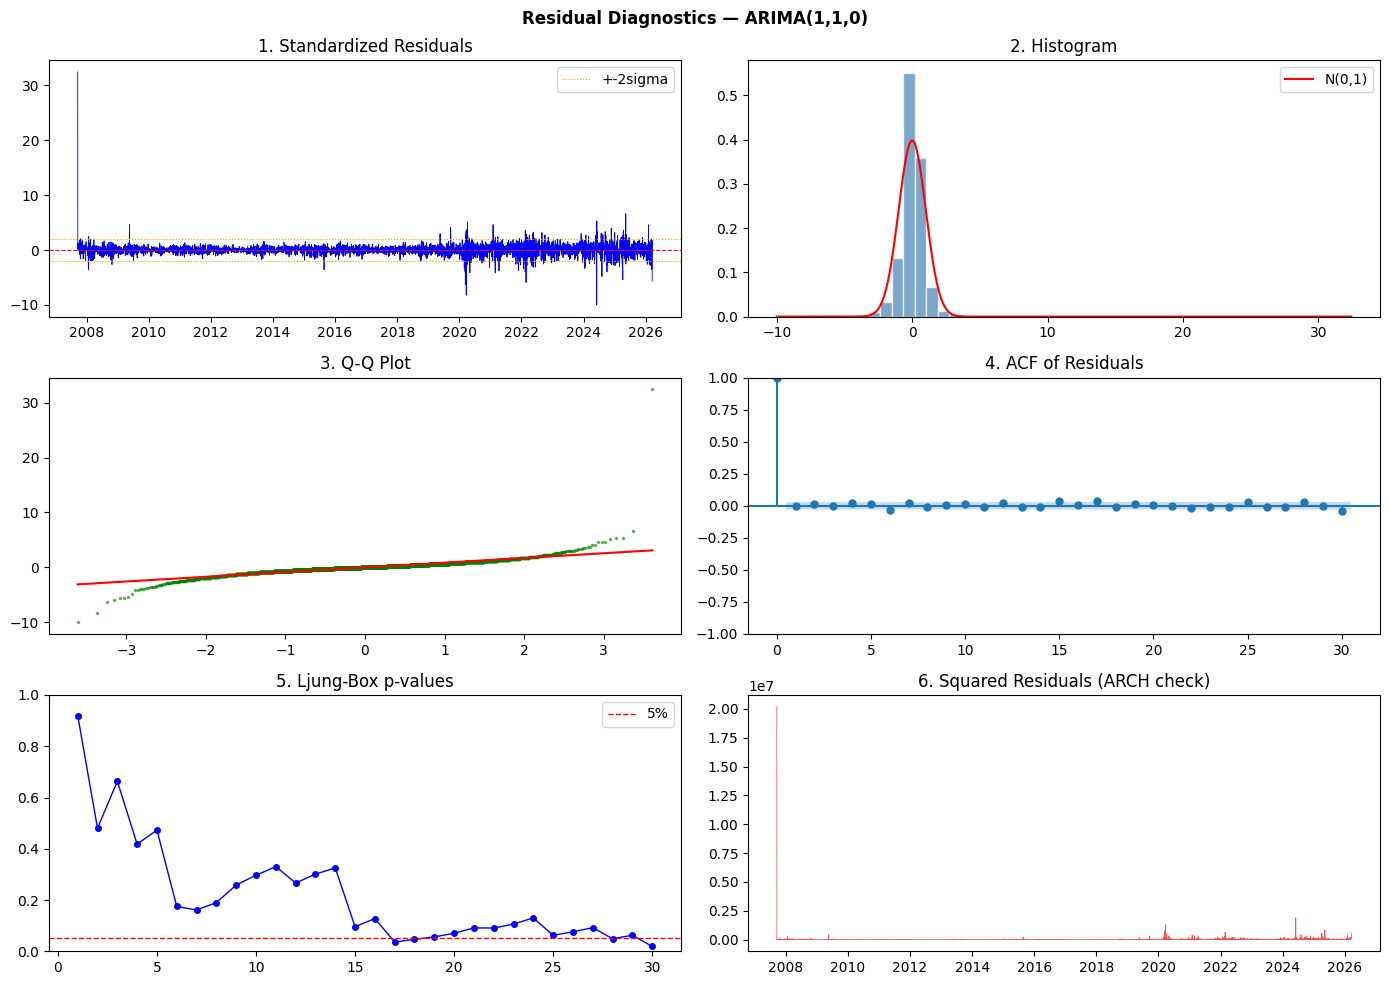


-------------------------------------------------------
  ARIMA(1,1,0)
-------------------------------------------------------
  1. Std Resid  : 3.35% outside +-2 sigma (expect ~5%)
  2. Normality  : Skew=7.0298  Kurt=248.9024  JB p=0.000000
               -> DEVIATION from normality
  5. Ljung-Box  : 4/30 lags have p < 0.05
               -> Autocorrelation present
  6. ARCH       : p=0.000000  -> ARCH effects present -- consider GARCH
  7. PMSE       : 19196.4002


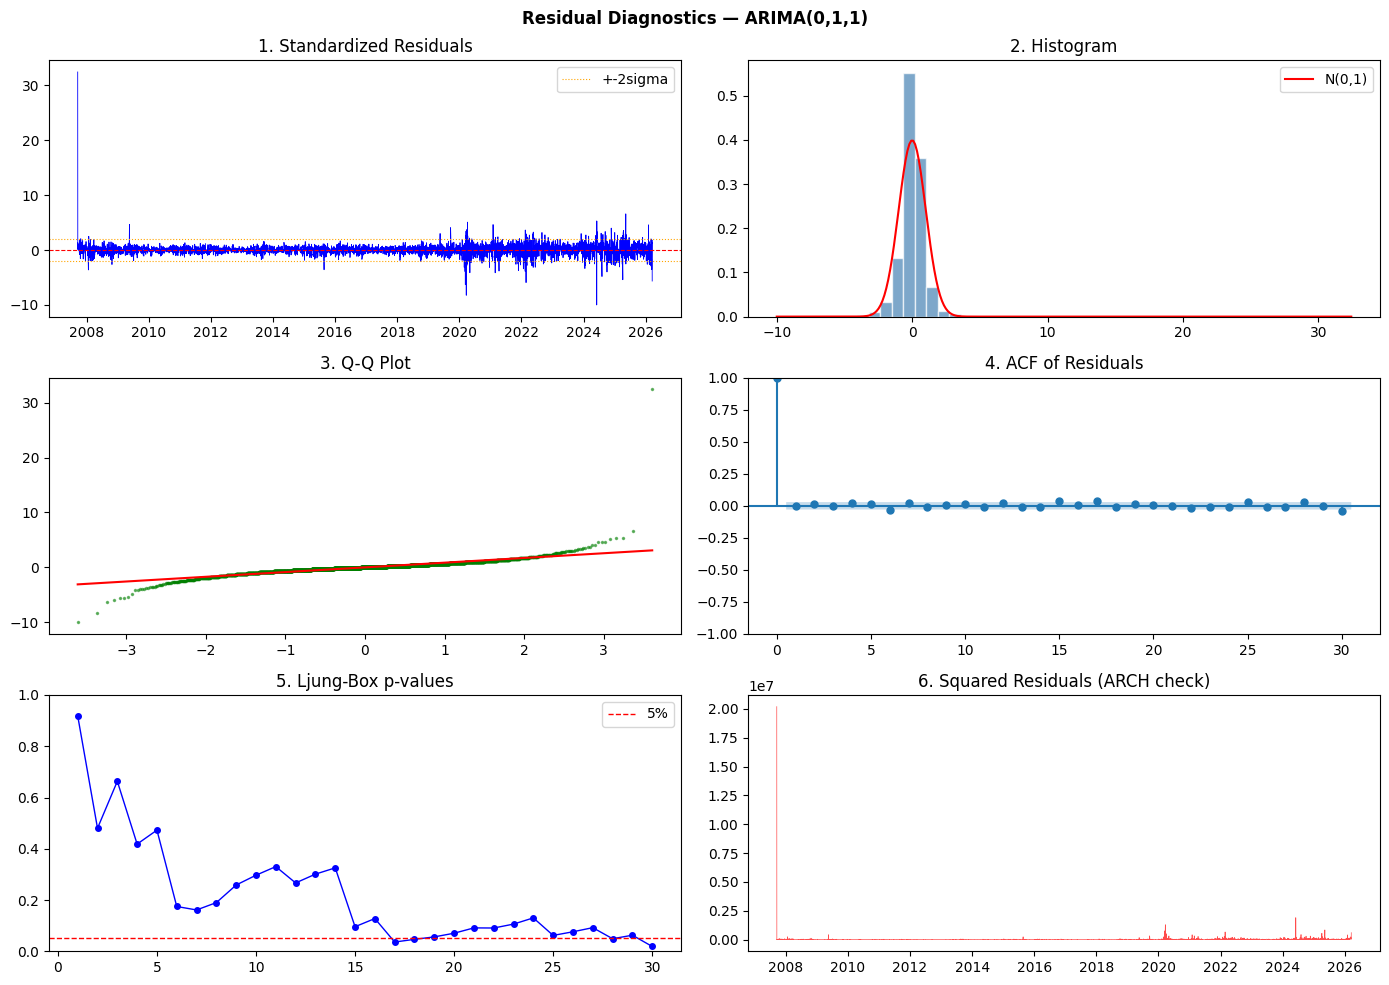


-------------------------------------------------------
  ARIMA(0,1,1)
-------------------------------------------------------
  1. Std Resid  : 3.35% outside +-2 sigma (expect ~5%)
  2. Normality  : Skew=7.0298  Kurt=248.9021  JB p=0.000000
               -> DEVIATION from normality
  5. Ljung-Box  : 4/30 lags have p < 0.05
               -> Autocorrelation present
  6. ARCH       : p=0.000000  -> ARCH effects present -- consider GARCH
  7. PMSE       : 19196.4003


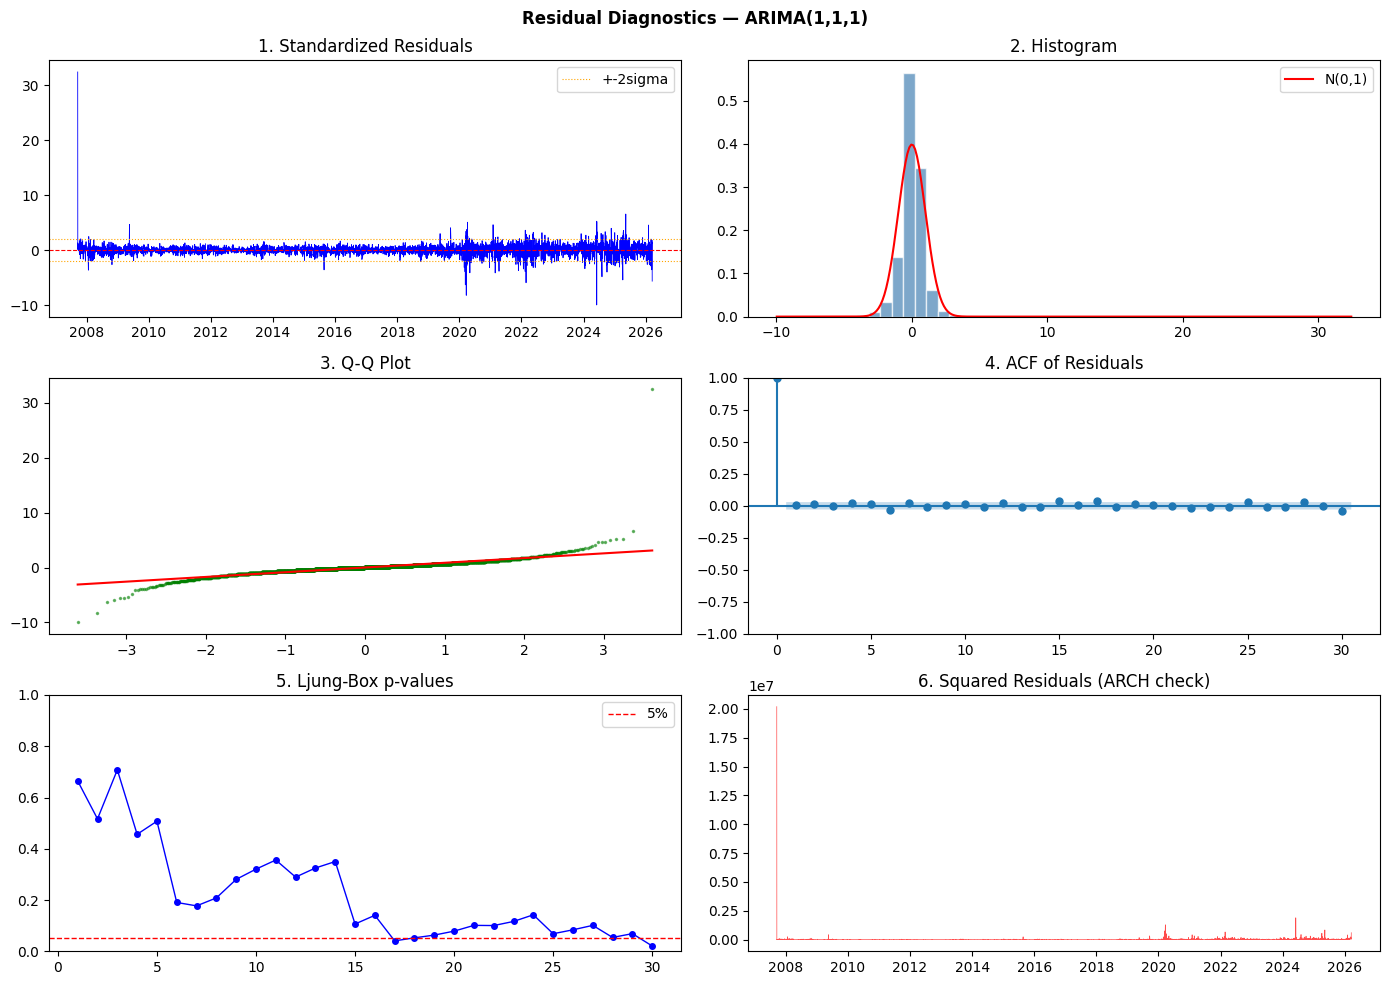


-------------------------------------------------------
  ARIMA(1,1,1)
-------------------------------------------------------
  1. Std Resid  : 3.35% outside +-2 sigma (expect ~5%)
  2. Normality  : Skew=7.0307  Kurt=248.8670  JB p=0.000000
               -> DEVIATION from normality
  5. Ljung-Box  : 2/30 lags have p < 0.05
               -> WHITE NOISE (residuals OK)
  6. ARCH       : p=0.000000  -> ARCH effects present -- consider GARCH
  7. PMSE       : 19195.7620


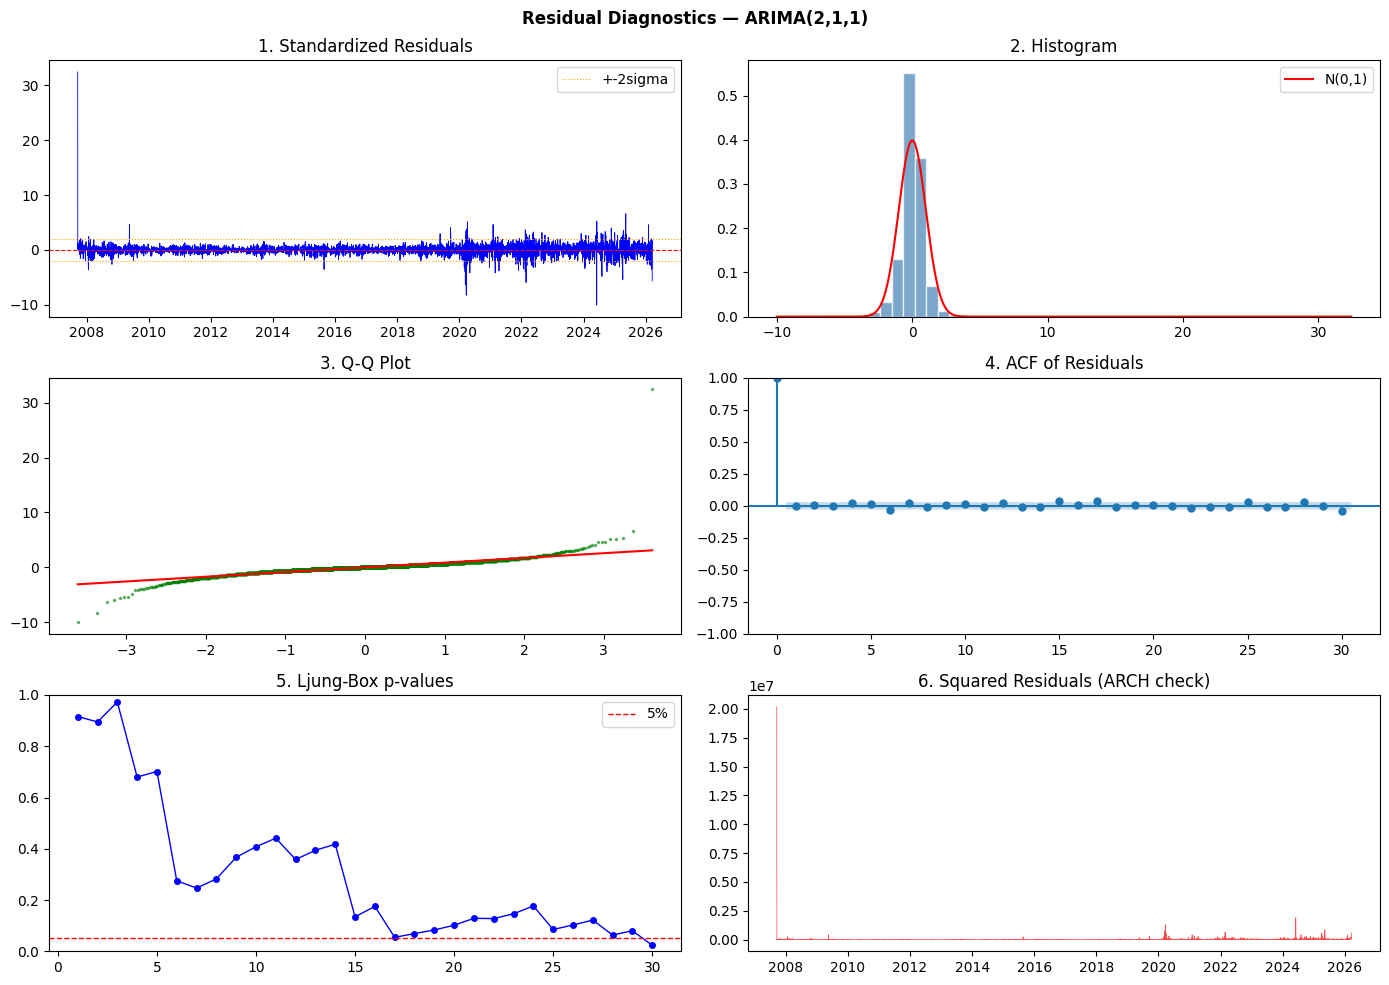


-------------------------------------------------------
  ARIMA(2,1,1)
-------------------------------------------------------
  1. Std Resid  : 3.30% outside +-2 sigma (expect ~5%)
  2. Normality  : Skew=7.0385  Kurt=248.9797  JB p=0.000000
               -> DEVIATION from normality
  5. Ljung-Box  : 1/30 lags have p < 0.05
               -> WHITE NOISE (residuals OK)
  6. ARCH       : p=0.000000  -> ARCH effects present -- consider GARCH
  7. PMSE       : 19192.8732


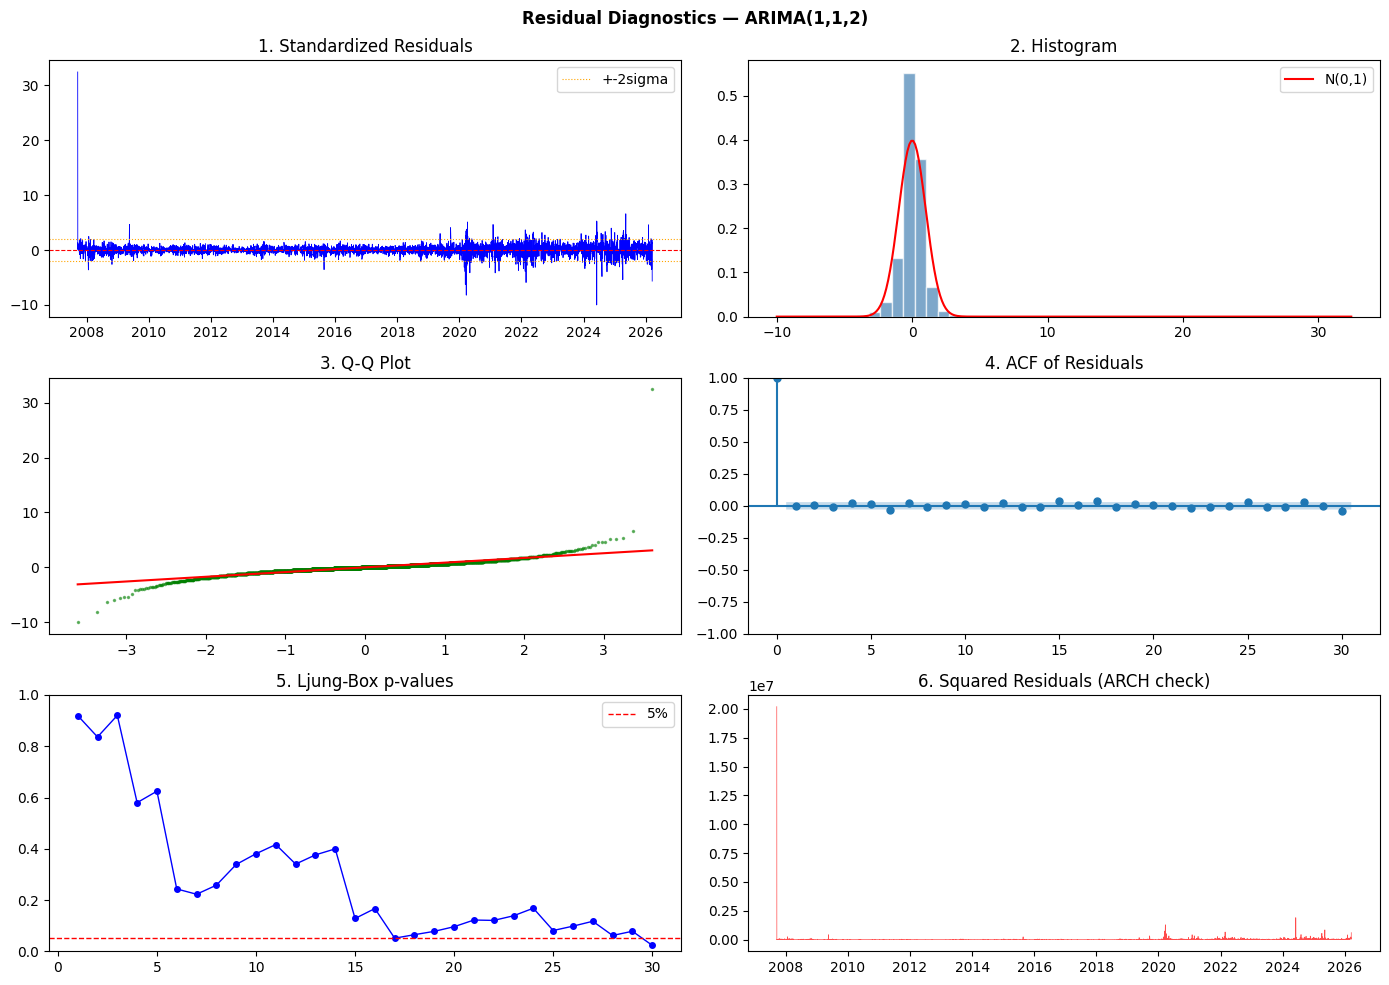


-------------------------------------------------------
  ARIMA(1,1,2)
-------------------------------------------------------
  1. Std Resid  : 3.30% outside +-2 sigma (expect ~5%)
  2. Normality  : Skew=7.0381  Kurt=248.9329  JB p=0.000000
               -> DEVIATION from normality
  5. Ljung-Box  : 1/30 lags have p < 0.05
               -> WHITE NOISE (residuals OK)
  6. ARCH       : p=0.000000  -> ARCH effects present -- consider GARCH
  7. PMSE       : 19194.2880


In [7]:
def residual_diagnostics(name, result):
    resid = result.resid.dropna()
    std_r = (resid - resid.mean()) / resid.std()

    fig, axes = plt.subplots(3, 2, figsize=(14, 10))

    # 1. Standardized residuals
    axes[0,0].plot(std_r.index, std_r.values, lw=0.6, color='b')
    axes[0,0].axhline( 0, color='red',    ls='--', lw=0.8)
    axes[0,0].axhline( 2, color='orange', ls=':',  lw=0.8, label='+-2sigma')
    axes[0,0].axhline(-2, color='orange', ls=':',  lw=0.8)
    axes[0,0].set_title('1. Standardized Residuals'); axes[0,0].legend()

    # 2. Histogram
    axes[0,1].hist(std_r, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    xr = np.linspace(std_r.min(), std_r.max(), 300)
    axes[0,1].plot(xr, stats.norm.pdf(xr), 'r-', lw=1.5, label='N(0,1)')
    axes[0,1].set_title('2. Histogram'); axes[0,1].legend()

    # 3. Q-Q Plot
    (osm, osr), (slope, intercept, _) = stats.probplot(std_r)
    axes[1,0].plot(osm, osr, 'o', ms=1.5, color='g', alpha=0.5)
    axes[1,0].plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
    axes[1,0].set_title('3. Q-Q Plot')

    # 4. ACF of residuals
    plot_acf(std_r, lags=30, ax=axes[1,1], title='4. ACF of Residuals')

    # 5. Ljung-Box p-values
    lb = acorr_ljungbox(resid, lags=range(1, 31), return_df=True)
    axes[2,0].plot(lb.index, lb['lb_pvalue'], 'bo-', ms=4, lw=1)
    axes[2,0].axhline(0.05, color='red', ls='--', lw=1, label='5%')
    axes[2,0].set_title('5. Ljung-Box p-values')
    axes[2,0].set_ylim(0, 1); axes[2,0].legend()

    # 6. Squared residuals (ARCH check)
    axes[2,1].plot(resid.index, resid.values**2, lw=0.5, color='r', alpha=0.7)
    axes[2,1].set_title('6. Squared Residuals (ARCH check)')

    plt.suptitle(f'Residual Diagnostics — {name}', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Print numeric summary
    pct_out = (np.abs(std_r) > 2).mean() * 100
    sk      = stats.skew(std_r)
    ku      = stats.kurtosis(std_r)
    jb_s, jb_p = stats.jarque_bera(std_r)
    lb_sig  = (lb['lb_pvalue'] < 0.05).sum()
    pmse    = np.mean(resid**2)
    try:    arch_p = het_arch(resid, nlags=10)[1]
    except: arch_p = float('nan')

    print(f'\n' + '-'*55)
    print(f'  {name}')
    print('-'*55)
    print(f'  1. Std Resid  : {pct_out:.2f}% outside +-2 sigma (expect ~5%)')
    print(f'  2. Normality  : Skew={sk:.4f}  Kurt={ku:.4f}  JB p={jb_p:.6f}')
    print(f'               -> {"DEVIATION from normality" if jb_p < 0.05 else "Approx normal"}')
    print(f'  5. Ljung-Box  : {lb_sig}/30 lags have p < 0.05')
    print(f'               -> {"Autocorrelation present" if lb_sig > 2 else "WHITE NOISE (residuals OK)"}')
    print(f'  6. ARCH       : p={arch_p:.6f}  -> {"ARCH effects present -- consider GARCH" if arch_p < 0.05 else "No ARCH effects"}')
    print(f'  7. PMSE       : {pmse:.4f}')


for name, result in fitted.items():
    residual_diagnostics(name, result)

7(d.8): Final Ranking — AIC, AICc, BIC

FULL RANKING TABLE:
                     AIC        AICc         BIC        PMSE      RMSE       MAE      R2    LB_p  JB_p  ARCH_p
Model                                                                                                         
ARIMA(1,1,0)  56454.9457  56454.9484  56467.7866  19196.4002  277.8167  235.6027 -0.0649  0.2968   0.0     0.0
ARIMA(0,1,1)  56454.9458  56454.9484  56467.7867  19196.4003  277.8225  235.6074 -0.0650  0.2968   0.0     0.0
ARIMA(1,1,1)  56456.7493  56456.7546  56476.0107  19195.7620  278.4735  236.0227 -0.0700  0.3206   0.0     0.0
ARIMA(2,1,1)  56457.8599  56457.8687  56483.5418  19192.8732  274.7167  232.3740 -0.0413  0.4078   0.0     0.0
ARIMA(1,1,2)  56458.2971  56458.3060  56483.9790  19194.2880  275.4929  232.3880 -0.0472  0.3806   0.0     0.0

  BEST MODEL (AIC / AICc / BIC): ARIMA(1,1,0)
  AIC  = 56454.95
  AICc = 56454.95
  BIC  = 56467.79
  RMSE = 277.82


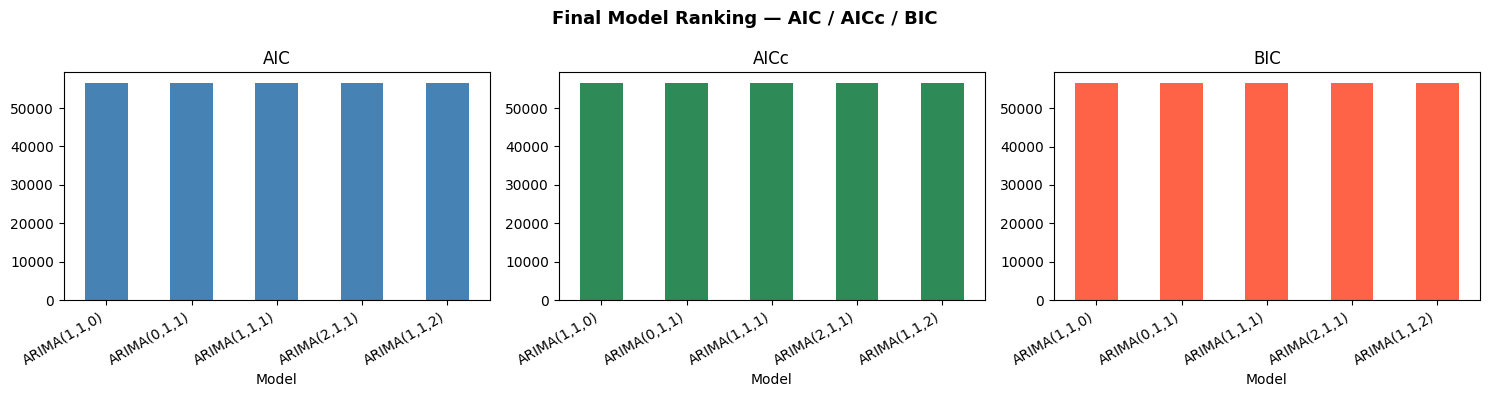

In [8]:
rows = []
for name, res in fitted.items():
    n     = len(res.resid.dropna())
    k     = len(res.params)
    aicc  = res.aic + (2 * k * (k + 1)) / (n - k - 1)
    resid = res.resid.dropna()
    lb_p  = acorr_ljungbox(resid, lags=[10], return_df=True)['lb_pvalue'].values[0]
    jb_p  = stats.jarque_bera(resid)[1]
    try:    arch_p = het_arch(resid, nlags=10)[1]
    except: arch_p = float('nan')
    pmse  = np.mean(resid**2)
    rmse, mae, r2 = metrics[name]
    rows.append({'Model': name, 'AIC': res.aic, 'AICc': aicc, 'BIC': res.bic,
                 'PMSE': pmse, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
                 'LB_p': lb_p, 'JB_p': jb_p, 'ARCH_p': arch_p})

df_rank = pd.DataFrame(rows).set_index('Model').sort_values('AIC')

print('FULL RANKING TABLE:')
print(df_rank.round(4).to_string())

best = df_rank.index[0]
print(f'\n' + '='*50)
print(f'  BEST MODEL (AIC / AICc / BIC): {best}')
print(f'  AIC  = {df_rank.loc[best, "AIC"]:.2f}')
print(f'  AICc = {df_rank.loc[best, "AICc"]:.2f}')
print(f'  BIC  = {df_rank.loc[best, "BIC"]:.2f}')
print(f'  RMSE = {df_rank.loc[best, "RMSE"]:.2f}')
print('='*50)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['AIC','AICc','BIC'], ['steelblue','seagreen','tomato']):
    df_rank[col].plot(kind='bar', ax=ax, color=color, title=col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.suptitle('Final Model Ranking — AIC / AICc / BIC', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()